# **Predicting Crisis Referral Risk within 90 Days**

This notebook cleans a community mental health dataset, explores it, engineers features, and trains/compares Logistic Regression and Random Forest models to predict whether a patient will have a crisis referral within 90 days of their index point. It closes with a decision-threshold analysis, risk tiering, and a summary of findings and recommendations.


## 1. Setup

### 1.1 Install required libraries
Uncomment and run if any of these are not already installed in your environment.

In [52]:
#!pip install numpy
#!pip install matplotlib
#!pip install pandas
#!pip install scikit-learn
#!pip install seaborn

### 1.2 Import libraries

In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, roc_auc_score, average_precision_score,
    precision_score, recall_score
)

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

# Shared colour palette for plots, defined once and reused throughout
PALETTE_2 = ['#FDD20E', '#F93822'] 

## 2. Load Dataset

In [54]:
df = pd.read_excel(
    r'Data Scientist - Practical Task - Dataset.xlsx',sheet_name = 'Supporting Dataset')
df.head()


,Patient_ID,Age,Gender,Ethnicity,IMD_Decile,Postcode_District,Team,Referral_Source,Referral_Date,Last_Contact_Date,Discharge_Date,Primary_Diagnosis,LTC_Count,Previous_Admissions,AE_Visits_Last12M,Appointments_Attended_Last12M,DNA_Count_Last12M,Crisis_Contacts_Last12M,Care_Coordinator_Allocated,Medication_Count,Smoking_Status,BMI,HbA1c,PHQ9_Score,GAD7_Score,Days_Since_Last_Contact,Post_Index_Crisis_Flag,Outcome_Crisis_Referral_90D
0,P100001,45,Male,Black Caribbean,9.0,WV10,North CMHT,IAPT,2025-06-14,2026-04-19,2026-09-28,Anxiety,1,0,0,8,1,0,NaN,3,Never,8.5,NaN,7.0,NaN,43,No,0
1,P100002,54,Male,White British,5.0,NaN,West CMHT,Unknown,2025-07-13,2026-02-03,2027-02-14,Anxiety,1,1,1,6,1,0,Yes,2,Former,23.4,47.2,NaN,17.0,118,No,0
2,P100003,16,Female,Black Caribbean,2.0,NaN,Early Intervention,Police,2025-09-05,2026-05-19,NaN,NaN,4,1,1,3,3,0,Yes,5,Never,24.8,45.1,2.0,10.0,13,No,0
3,P100004,49,Male,NaN,5.0,ST17,South CMHT,Social Care,2024-07-14,2026-05-10,NaN,Depression,1,1,2,17,4,2,Yes,2,Former,31.7,57.7,13.0,2.0,22,Yes,1
4,P100005,63,Male,White British,9.0,ST16,North CMHT,NaN,2025-02-27,2025-05-09,2025-11-10,PTSD,1,0,0,12,0,0,Yes,1,Current,31.1,50.4,12.0,12.0,388,No,0


In [55]:
# Keep an untouched copy of the raw data so cleaning steps can be compared against it later
original_df = df.copy()

In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2040 entries, 0 to 2039
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Patient_ID                     2040 non-null   object 
 1   Age                            2040 non-null   int64  
 2   Gender                         1925 non-null   object 
 3   Ethnicity                      1868 non-null   object 
 4   IMD_Decile                     2016 non-null   float64
 5   Postcode_District              1862 non-null   object 
 6   Team                           2040 non-null   object 
 7   Referral_Source                1750 non-null   object 
 8   Referral_Date                  2040 non-null   object 
 9   Last_Contact_Date              2040 non-null   object 
 10  Discharge_Date                 595 non-null    object 
 11  Primary_Diagnosis              1939 non-null   object 
 12  LTC_Count                      2040 non-null   i

## 3. Data Cleaning and Preprocessing
- Convert date columns to proper datetime format
- Handle duplicate records
- Handle missing data
- Resolve categorical inconsistencies
- Treat outliers in numeric fields


In [57]:
# The date columns are loaded as text; convert them to proper datetime format
df[["Referral_Date", "Last_Contact_Date", "Discharge_Date"]] = df[["Referral_Date", "Last_Contact_Date", "Discharge_Date"]].apply(
    pd.to_datetime, errors='coerce'
)

# Strip any leading/trailing whitespace that may remain in text-typed date columns
df[["Referral_Date", "Last_Contact_Date", "Discharge_Date"]] = df[["Referral_Date", "Last_Contact_Date", "Discharge_Date"]].apply(
    lambda x: x.str.strip() if x.dtype == "object" else x
)

# Handle duplicates
n_duplicates = df['Patient_ID'].duplicated().sum()
print(f"{n_duplicates} duplicate Patient_IDs found")

# Inspect the duplicated rows before dropping them
duplicates = df[df.duplicated("Patient_ID", keep=False)].sort_values('Patient_ID')
duplicates.head()

# These are exact duplicates, so it is safe to drop them, keeping the first occurrence
df = df.drop_duplicates(subset='Patient_ID', keep='first')

# Confirm the duplicates have been removed and check the resulting shape
df['Patient_ID'].duplicated().sum() == 0
df.shape


40 duplicate Patient_IDs found


(2000, 28)

We are proceeding with 2,000 records.

### 3.1 Handle Missing Data

In [58]:
#% of missing values in each column
missing_percent = (df.isnull().sum() / len(df)) * 100
#list of columns with missing values in descending order
missing_percent= missing_percent[missing_percent != 0].sort_values(ascending=False)
missing_percent

Discharge_Date                70.75
Smoking_Status                20.35
HbA1c                         17.35
Referral_Source               14.25
GAD7_Score                    12.40
PHQ9_Score                    11.45
Postcode_District              8.70
Ethnicity                      8.40
Care_Coordinator_Allocated     6.70
BMI                            6.35
Gender                         5.50
Primary_Diagnosis              5.00
Post_Index_Crisis_Flag         3.60
IMD_Decile                     1.20
dtype: float64

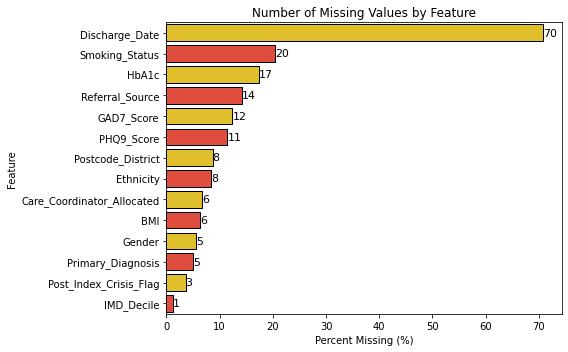

In [59]:
missing_df = pd.DataFrame(missing_percent.items(), columns=['Feature', 'Percent Missing (%)'])
mis_df = missing_df.sort_values('Percent Missing (%)', ascending=False)

colors = ['#FDD20E', '#F93822']

plt.figure(figsize=(8,5))
ax = sns.barplot(data=mis_df, x='Percent Missing (%)', y='Feature', palette=colors, edgecolor='black')

for container in ax.containers:
    ax.bar_label(container, fmt='%d', fontsize=11)

plt.title('Number of Missing Values by Feature')
plt.xlabel('Percent Missing (%)')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

Discharge_Date has a high proportion of missing values, but that is expected: a blank value means the case is still open (not yet discharged).

In [60]:
# we cant assume ethnicity, and Primary_Diagnosis  are missing at random, so we will create a new category called 'Unknown' for missing values in
df[['Ethnicity', 'Referral_Source', 'Primary_Diagnosis']] = (
    df[['Ethnicity', 'Referral_Source', 'Primary_Diagnosis']].fillna('Unknown')
)

#for columns with float datatype, use median for imputation
for col in df.select_dtypes(include=['float64']).columns:
    df[col].fillna(df[col].median(), inplace=True)

#use mode for smoking status and Care_Coordinator_Allocated
for col in ['Smoking_Status', 'Care_Coordinator_Allocated']:
    df[col] = df[col].fillna(df[col].mode()[0])

#check for any remaining missing values
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_percent[missing_percent != 0].sort_values(ascending=False)


Discharge_Date            70.75
Postcode_District          8.70
Gender                     5.50
Post_Index_Crisis_Flag     3.60
dtype: float64

Before handling `Gender`, check the raw distribution of values.

In [61]:
# before handling gender, check the distribution and fill in missing values with 'Unknown'
df['Gender'].value_counts()

Male       778
Female     747
Unknown    106
M           81
F           67
male        58
female      53
Name: Gender, dtype: int64

In [62]:
# The raw values are inconsistent (mixed case, abbreviations); standardise to Male / Female / Unknown
df['Gender'] = (
    df['Gender'].astype(str).str.strip().str.lower().map({
        'm': 'Male',
        'male': 'Male',
        'f': 'Female',
        'female': 'Female'
    })
    .fillna('Unknown')
)

# Check the cleaned gender distribution
df['Gender'].value_counts()

# Confirm no missing values remain outside of the expected columns
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_percent[missing_percent != 0].sort_values(ascending=False)


Discharge_Date            70.75
Postcode_District          8.70
Post_Index_Crisis_Flag     3.60
dtype: float64

We will handle these 3 later: create a new cloumn based on Discharge_date, drop Post_Index as it is not relevant to this analysis and would cause multicollinearity. Also drop Postcode_District as IMD_Decile conveys information about the demographic.

### 3.2 Handle Other Inconsistencies

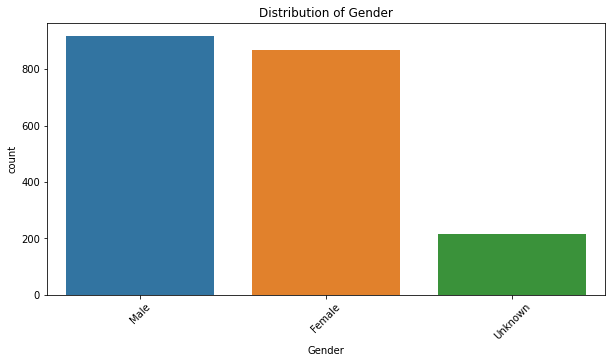

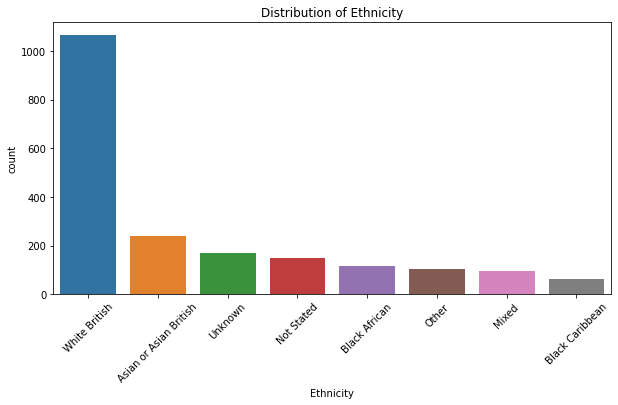

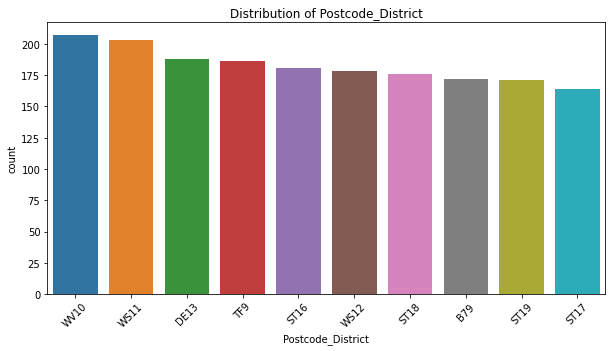

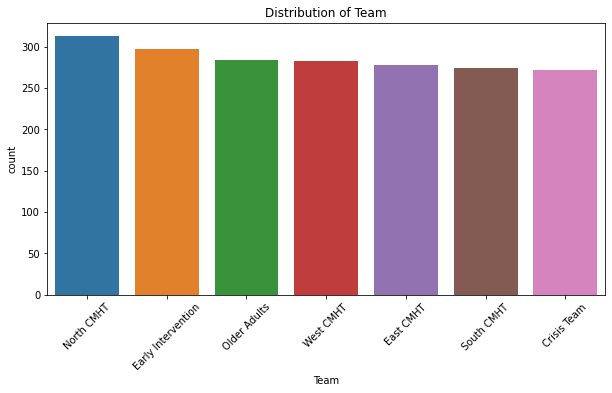

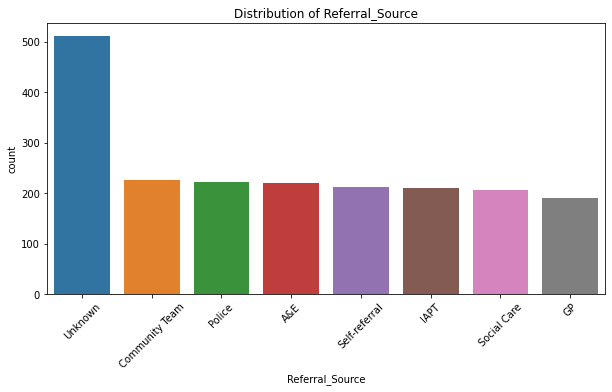

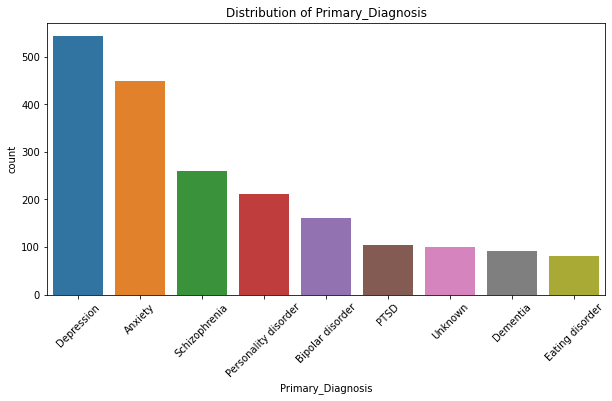

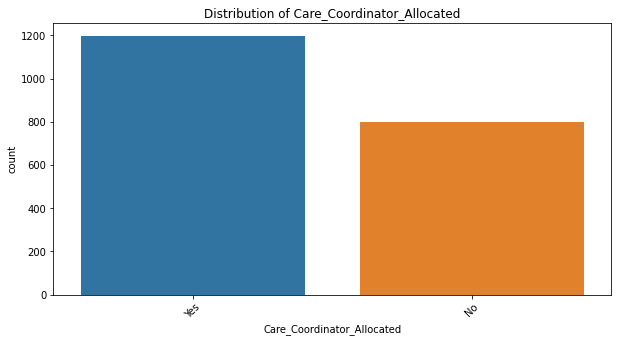

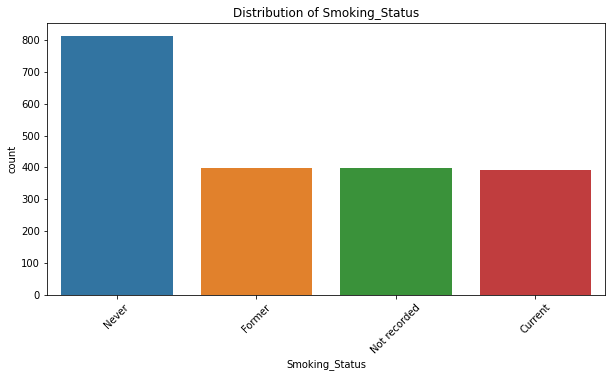

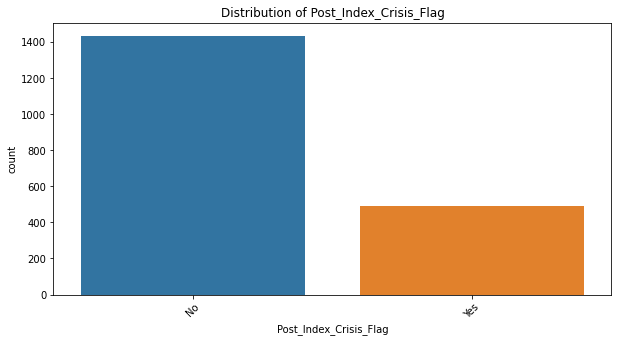

In [63]:
#with bar charts, check distribution of all categorical variables, except date columns and patient_id
categorical_cols = df.select_dtypes(include=['object', 'category']).columns
categorical_cols = categorical_cols.drop(['Referral_Date', 'Last_Contact_Date', 'Patient_ID'], errors='ignore')

#use bar charts to visualize the distribution of categorical variables
for col in categorical_cols:
    plt.figure(figsize=(10, 5))
    sns.countplot(data=df, x=col, order=df[col].value_counts().index)
    plt.title(f'Distribution of {col}')
    plt.xticks(rotation=45)
    plt.show()

In [64]:
# Group 'Unknown' and 'Not Stated' into a single 'Unknown/Not Stated' category for Ethnicity
df['Ethnicity'] = df['Ethnicity'].replace(['Unknown', 'Not Stated'], 'Unknown/Not Stated')

# Check the proportion of 'Unknown' values in Referral_Source
df['Referral_Source'].isin(['Unknown']).mean() * 100


25.6

Referral_Source has "Unknown" as its most common value, at 25.6%. Leaving it as-is for now, rather than dropping it, to avoid losing too much data — this could be revisited by grouping it with other categories if needed.

### 3.3 Outlier Treatment

In [65]:
# Check numerical variables
df.describe()


,Age,IMD_Decile,LTC_Count,Previous_Admissions,AE_Visits_Last12M,Appointments_Attended_Last12M,DNA_Count_Last12M,Crisis_Contacts_Last12M,Medication_Count,BMI,HbA1c,PHQ9_Score,GAD7_Score,Days_Since_Last_Contact,Outcome_Crisis_Referral_90D
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.00000,2000.000000,2000.00000
mean,48.124000,5.492000,1.210000,0.558000,1.051000,12.188000,2.464000,0.372500,2.610500,28.190450,44.742350,12.74000,9.63950,178.067500,0.25650
std,17.664785,2.995066,1.052356,0.934919,1.519392,19.835079,6.819601,0.741632,1.860785,7.987484,10.784443,5.50632,4.55334,168.273976,0.43681
min,-4.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.300000,7.100000,0.00000,0.00000,-20.000000,0.00000
25%,36.000000,3.000000,0.000000,0.000000,0.000000,5.000000,0.000000,0.000000,1.000000,24.300000,38.900000,9.00000,7.00000,42.750000,0.00000
50%,48.000000,6.000000,1.000000,0.000000,1.000000,10.000000,2.000000,0.000000,3.000000,27.900000,44.800000,13.00000,10.00000,132.000000,0.00000
75%,60.000000,8.000000,2.000000,1.000000,2.000000,14.000000,3.000000,1.000000,4.000000,31.300000,50.800000,16.00000,12.00000,280.250000,1.00000
max,112.000000,11.000000,5.000000,7.000000,15.000000,200.000000,75.000000,8.000000,9.000000,120.000000,87.600000,27.00000,21.00000,767.000000,1.00000


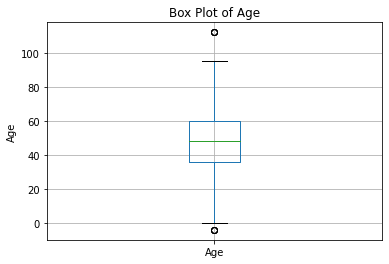

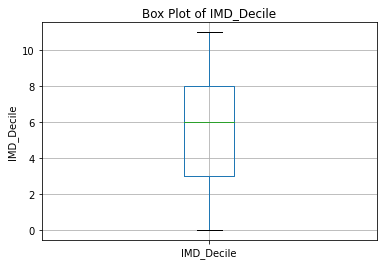

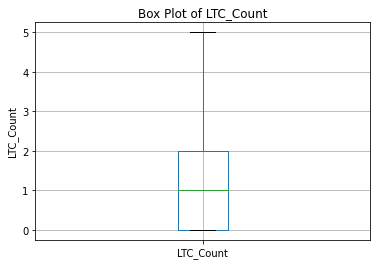

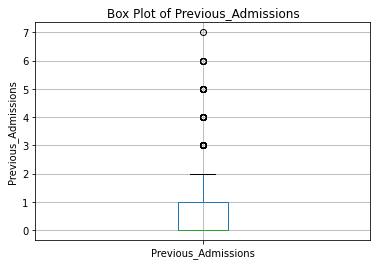

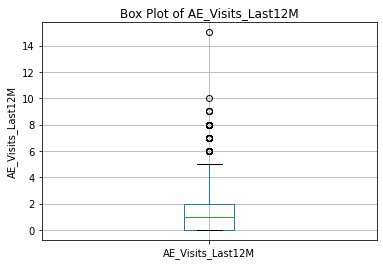

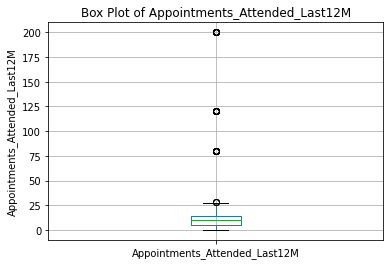

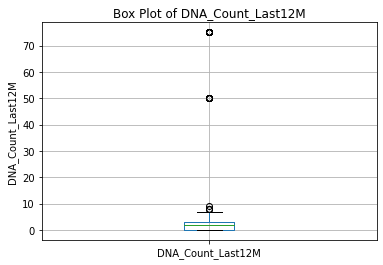

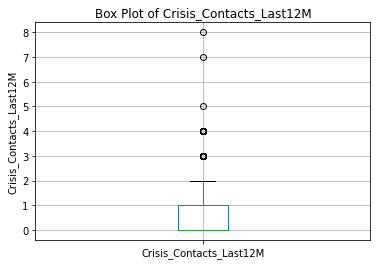

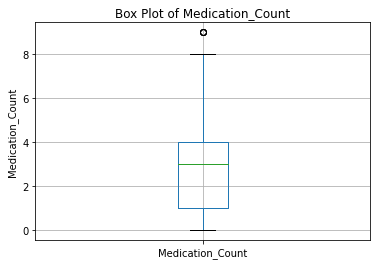

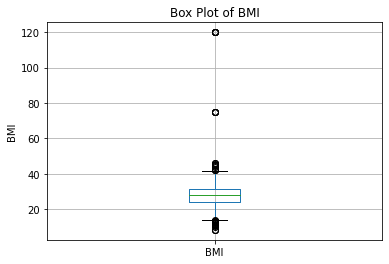

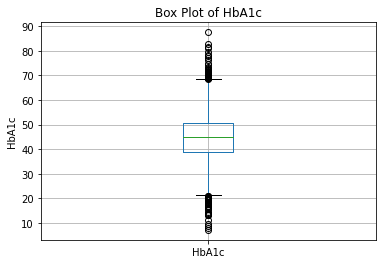

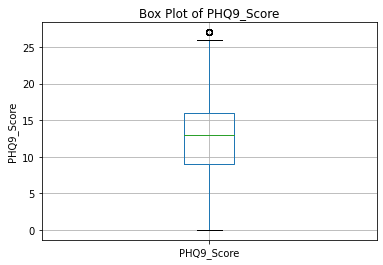

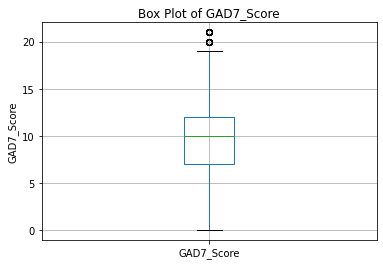

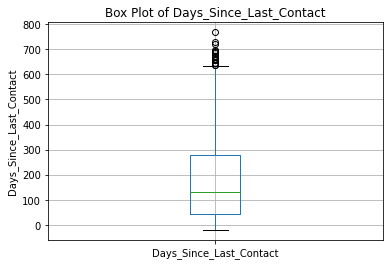

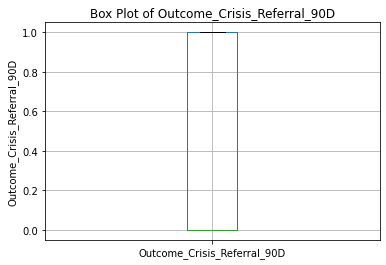

In [66]:
#box plot for all numerical columns to check for outliers
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.drop('Patient_ID', errors='ignore')

for col in numerical_cols:
    plt.figure(figsize=(6, 4))
    df.boxplot(column=col)
    plt.title(f'Box Plot of {col}')
    plt.ylabel(col)
    plt.show()

In [67]:
# Age has a minimum of -4, which is not valid; replace negative values and values above the
# 99th percentile with the median age
df['Age'] = df['Age'].apply(lambda x: df['Age'].median() if x < 16 or x > df['Age'].quantile(0.99) else x)

# IMD_Decile should range from 1 to 10; clip values outside that range
df['IMD_Decile'] = df['IMD_Decile'].apply(lambda x: 1 if x < 1 else (10 if x > 10 else x))

# Appointments_Attended_Last12M has a max of 200, which is an outlier; replace values above the
# 99th percentile with the median
df['Appointments_Attended_Last12M'] = df['Appointments_Attended_Last12M'].apply(
    lambda x: df['Appointments_Attended_Last12M'].median() if x > df['Appointments_Attended_Last12M'].quantile(0.99) else x
)

# DNA_Count_Last12M also contains outliers; replace values above the 99th percentile with the median
df['DNA_Count_Last12M'] = df['DNA_Count_Last12M'].apply(
    lambda x: df['DNA_Count_Last12M'].median() if x > df['DNA_Count_Last12M'].quantile(0.99) else x
)

# BMI also contains outliers; replace values below the 1st percentile or above the 99th percentile
# with the median
df['BMI'] = df['BMI'].apply(
    lambda x: df['BMI'].median() if x < df['BMI'].quantile(0.01) or x > df['BMI'].quantile(0.99) else x
)

# Days_Since_Last_Contact has negative values, which are not possible; set these to missing
df.loc[df['Days_Since_Last_Contact'] < 0, 'Days_Since_Last_Contact'] = np.nan

# Use the untouched original_df to count how many records were affected by each outlier rule above,
# for transparency on the scale of the corrections made
outlier_affected_records = {
    'Age': original_df[original_df['Age'] < 16].shape[0] + original_df[original_df['Age'] > original_df['Age'].quantile(0.99)].shape[0],
    'IMD_Decile': original_df[(original_df['IMD_Decile'] < 1) | (original_df['IMD_Decile'] > 10)].shape[0],
    'Appointments_Attended_Last12M': original_df[original_df['Appointments_Attended_Last12M'] > original_df['Appointments_Attended_Last12M'].quantile(0.99)].shape[0],
    'DNA_Count_Last12M': original_df[original_df['DNA_Count_Last12M'] > original_df['DNA_Count_Last12M'].quantile(0.99)].shape[0],
    'BMI': original_df[original_df['BMI'] < original_df['BMI'].quantile(0.01)].shape[0] + original_df[original_df['BMI'] > original_df['BMI'].quantile(0.99)].shape[0],
    'Days_Since_Last_Contact': original_df[original_df['Days_Since_Last_Contact'] < 0].shape[0]
}
outlier_affected_records


{'Age': 33,
 'IMD_Decile': 57,
 'Appointments_Attended_Last12M': 14,
 'DNA_Count_Last12M': 21,
 'BMI': 40,
 'Days_Since_Last_Contact': 170}

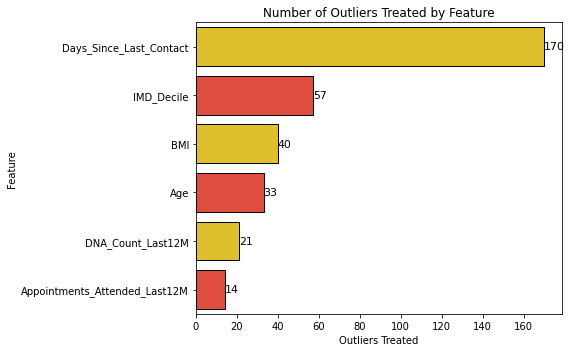

In [68]:
outlier_df = pd.DataFrame(outlier_affected_records.items(), columns=['Feature', 'Outliers Treated'])
outlier_df = outlier_df.sort_values('Outliers Treated', ascending=False)

colors = ['#FDD20E', '#F93822']

plt.figure(figsize=(8,5))
ax = sns.barplot(data=outlier_df, x='Outliers Treated', y='Feature', palette=colors, edgecolor='black')

for container in ax.containers:
    ax.bar_label(container, fmt='%d', fontsize=11)

plt.title('Number of Outliers Treated by Feature')
plt.xlabel('Outliers Treated')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

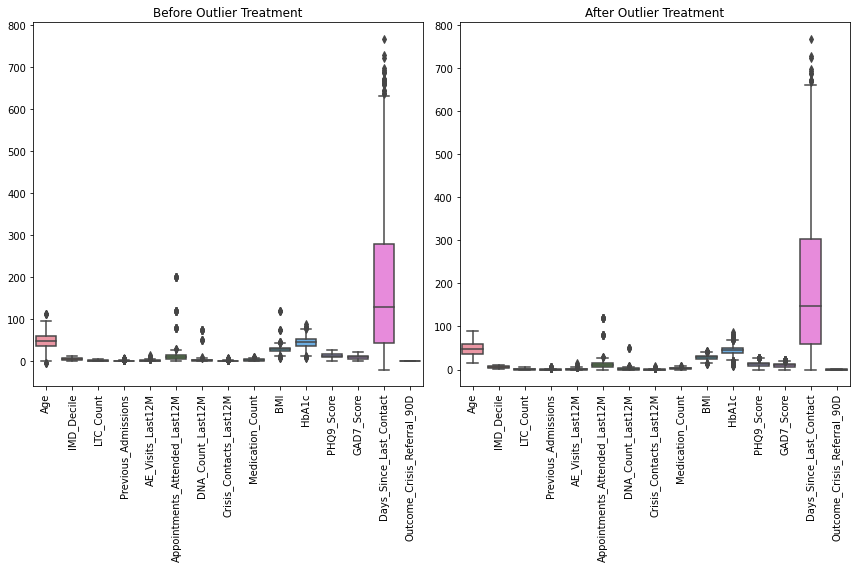

In [69]:
fig, ax = plt.subplots(1, 2, figsize=(12,8))

sns.boxplot(data=original_df[numerical_cols], ax=ax[0])
ax[0].set_title('Before Outlier Treatment')
ax[0].tick_params(axis='x', rotation=90)

sns.boxplot(data=df[numerical_cols], ax=ax[1])
ax[1].set_title('After Outlier Treatment')
ax[1].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

## 4. Exploratory Data Analysis
Explore the cleaned data.

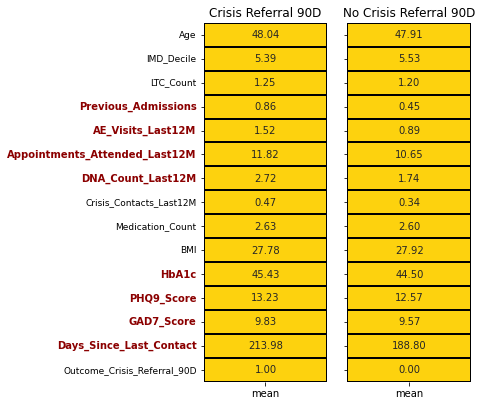

Top 8 features with largest mean differences:
Days_Since_Last_Contact          25.182942
Appointments_Attended_Last12M     1.169619
DNA_Count_Last12M                 0.978949
HbA1c                             0.927006
PHQ9_Score                        0.656449
AE_Visits_Last12M                 0.626186
Previous_Admissions               0.403093
GAD7_Score                        0.256771
Name: mean, dtype: float64


In [70]:
# Comparing mean values of numeric features between outcome groups
# Keep all numeric columns but exclude the target from highlighting

target = 'Outcome_Crisis_Referral_90D'

yes = df[df[target] == 1].describe().T
no = df[df[target] == 0].describe().T

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(7, 6))

colors = ['#FDD20E']

sns.heatmap(
    yes[['mean']],
    annot=True,
    cmap=colors,
    linewidths=0.4,
    linecolor='black',
    cbar=False,
    fmt='.2f',
    ax=ax[0]
)
ax[0].set_title('Crisis Referral 90D')
ax[0].set_xlabel('')
ax[0].set_ylabel('')

sns.heatmap(
    no[['mean']],
    annot=True,
    cmap=colors,
    linewidths=0.4,
    linecolor='black',
    cbar=False,
    fmt='.2f',
    ax=ax[1]
)
ax[1].set_title('No Crisis Referral 90D')
ax[1].set_xlabel('')
ax[1].set_ylabel('')
ax[1].set_yticklabels([])

# Calculate top 8 features with largest mean differences
mean_diff = (yes['mean'] - no['mean']).abs()
mean_diff = mean_diff.drop(target, errors='ignore')

top8 = mean_diff.nlargest(8).index

# Bold top 8 y-axis labels on first heatmap
for label in ax[0].get_yticklabels():
    if label.get_text() in top8:
        label.set_fontweight('bold')
        label.set_color('darkred')
        label.set_fontsize(10)
    else:
        label.set_fontweight('normal')
        label.set_fontsize(9)

fig.tight_layout(pad=2)
plt.show()

print("Top 8 features with largest mean differences:")
print(mean_diff.nlargest(8))

- **Previous_Admissions** is much higher in the crisis group (0.86 vs 0.45) — patients with previous admissions appear more likely to have a crisis referral.
- **AE_Visits_Last12M** is considerably higher in the crisis group (1.52 vs 0.89), suggesting previous A&E use is associated with future crisis.
- **Appointments_Attended_Last12M** is slightly higher (11.82 vs 10.65), which may indicate greater service use.
- **Days_Since_Last_Contact** is noticeably higher in the crisis group (214 vs 189 days). This may suggest longer gaps in contact are associated with increased crisis risk, although this should be interpreted alongside clinical context.
- **Crisis_Contact_Flag** is higher in the crisis group (0.32 vs 0.25) — previous crisis contact appears associated with future crisis referral.
- **DNA_Count_Flag** is higher in the crisis group (0.56 vs 0.49) — patients who missed appointments ("Did Not Attend") appear slightly more likely to have a crisis referral.

Other features are very similar between the two groups.


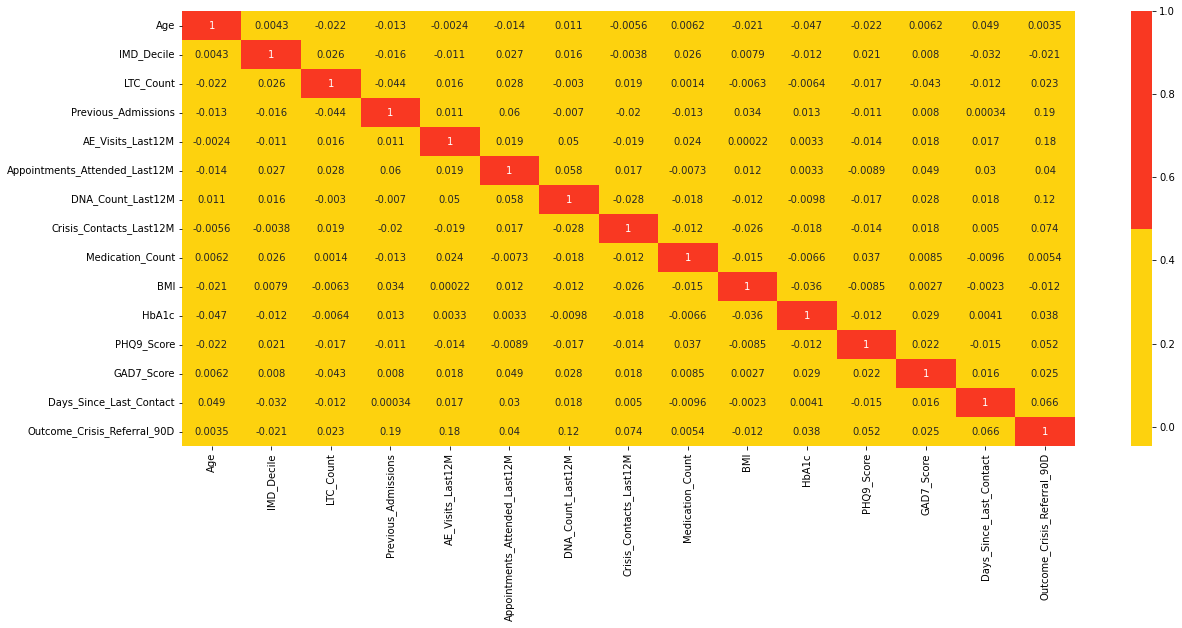

In [71]:
# plot correlation heatmap
colors = ['#FDD20E', '#F93822']
plt.figure(figsize = (20,8))
sns.heatmap(df.corr(),cmap = colors,annot = True);

The full correlation heatmap doesn't reveal much on its own — check the correlation of each feature with Crisis Referral specifically.

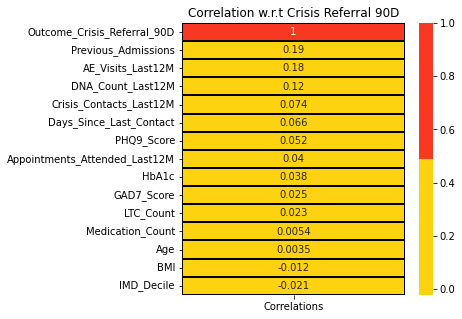

In [72]:
corr = df.corrwith(df['Outcome_Crisis_Referral_90D']).sort_values(ascending = False).to_frame()
corr.columns = ['Correlations']
plt.subplots(figsize = (5,5))
sns.heatmap(corr,annot = True,cmap = colors,linewidths = 0.4,linecolor = 'black');
plt.title('Correlation w.r.t Crisis Referral 90D');


Still no strongly correlated individual feature with Crisis Referral — consistent with this being a multi-factor outcome rather than one driven by a single variable.

### 4.1 Target Variable Balance
How balanced are the classes?

In [73]:
df['Outcome_Crisis_Referral_90D'].value_counts()

0    1487
1     513
Name: Outcome_Crisis_Referral_90D, dtype: int64

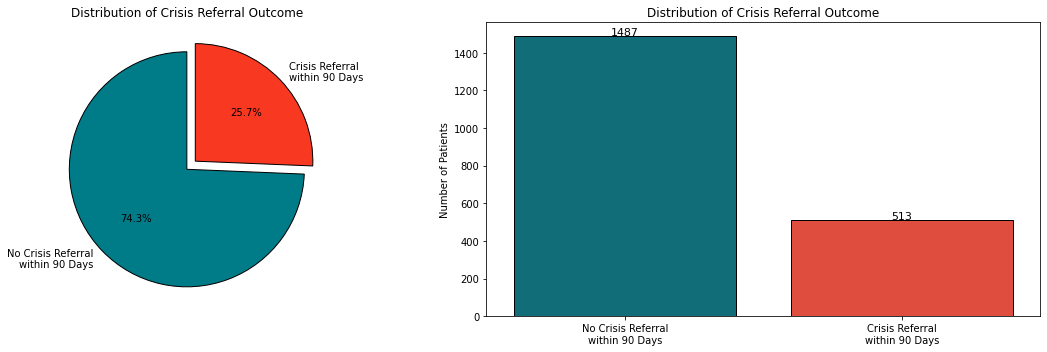

In [74]:
# Plot target variable distribution

l = list(df['Outcome_Crisis_Referral_90D'].value_counts().sort_index())
circle = [l[0] / sum(l) * 100, l[1] / sum(l) * 100]
colors = ['#007C89', '#F93822']

fig, ax = plt.subplots(1, 2, figsize=(16, 5))

# Pie chart
plt.subplot(1, 2, 1)
plt.pie(circle, labels=['No Crisis Referral\nwithin 90 Days', 'Crisis Referral\nwithin 90 Days'], autopct='%1.1f%%', startangle=90, explode=(0, 0.1), colors=colors, wedgeprops={'edgecolor':'black', 'linewidth':1, 'antialiased':True})
plt.title('Distribution of Crisis Referral Outcome')

# Bar chart
plt.subplot(1, 2, 2)
ax = sns.countplot(data=df, x='Outcome_Crisis_Referral_90D', palette=colors, edgecolor='black')
for rect in ax.patches:
    height = rect.get_height()
    ax.text(rect.get_x() + rect.get_width()/2, height + 5, f'{int(height)}', ha='center', fontsize=11)

ax.set_xticklabels(['No Crisis Referral\nwithin 90 Days', 'Crisis Referral\nwithin 90 Days'])
ax.set_xlabel('')
ax.set_ylabel('Number of Patients')
plt.title('Distribution of Crisis Referral Outcome')

plt.tight_layout()
plt.show()

About 25% of patients had a crisis referral within 90 days of their index point. Because of this class imbalance, we stratify the data for the train/test split and for cross-validation.

## 5. Feature Engineering

In [75]:
# Group some numeric scores into clinically meaningful categories to help with modelling

# GAD7_Score ranges 0-21: bucket into Minimal / Mild / Moderate / Severe
df['GAD7_Category'] = pd.cut(
    df['GAD7_Score'], bins=[0, 5, 10, 15, 22],
    labels=['Minimal', 'Mild', 'Moderate', 'Severe'], include_lowest=True
)

# PHQ9_Score ranges 0-27: bucket into Minimal / Mild / Moderate / Severe
df['PHQ9_Category'] = pd.cut(
    df['PHQ9_Score'], bins=[0, 5, 10, 15, 28],
    labels=['Minimal', 'Mild', 'Moderate', 'Severe'], include_lowest=True
)

# Group age into bands
df['Age_Group'] = pd.cut(
    df['Age'], bins=[15, 25, 35, 50, 65, np.inf],
    labels=['16-25', '26-35', '36-50', '51-65', '65+'], right=True
)

# Group IMD_Decile into Low (1-3) / Medium (4-7) / High (8-10) deprivation categories
df['IMD_Category'] = pd.cut(
    df['IMD_Decile'], bins=[0, 3, 7, 10],
    labels=['Low', 'Medium', 'High'], include_lowest=True
)

# Flag whether the patient had any crisis contacts in the last 12 months
df['Crisis_Contact_Flag'] = (df['Crisis_Contacts_Last12M'] > 0).astype(int)

# Flag patients with a high 'Did Not Attend' rate (above the 40th percentile of DNA_Count_Last12M)
df['DNA_Count_Flag'] = (df['DNA_Count_Last12M'] > df['DNA_Count_Last12M'].quantile(0.4)).astype(int)

# Convert Discharge_Date into a binary Is_Open_Case flag (missing date = case still open)
df['Is_Open_Case'] = df['Discharge_Date'].isnull().astype(int)

# Drop the raw columns that have been superseded by the new categorical/flag features above,
# to avoid multicollinearity in the model
df.drop(
    columns=['GAD7_Score', 'PHQ9_Score', 'Age', 'IMD_Decile', 'Crisis_Contacts_Last12M',
             'DNA_Count_Last12M', 'Discharge_Date'],
    inplace=True
)


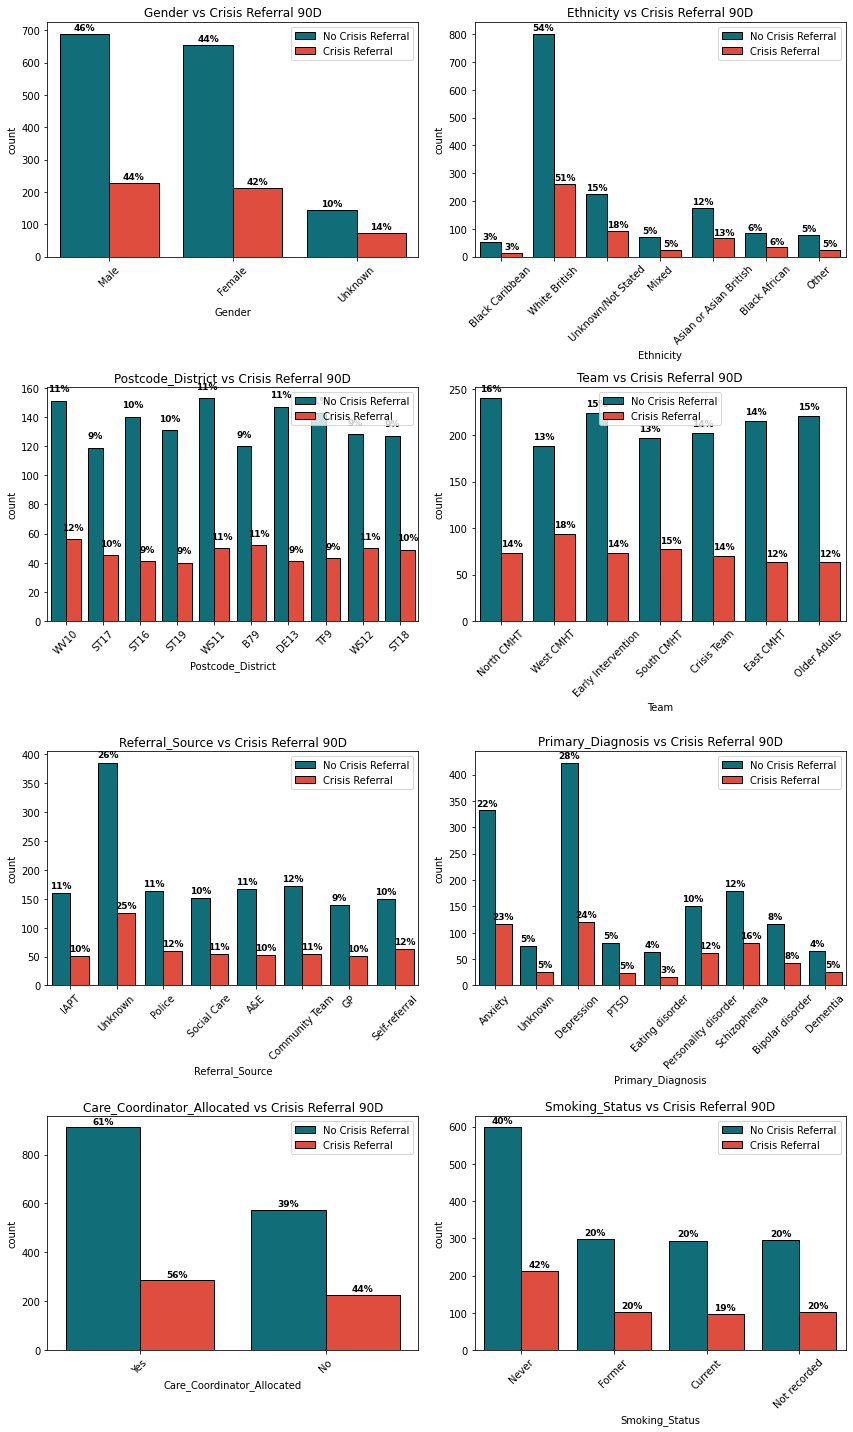

In [76]:
categorical_cols = [col for col in categorical_cols if col not in ['Patient_ID', 'Post_Index_Crisis_Flag']]

ncols = 2
nrows = math.ceil(len(categorical_cols) / ncols)

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(12, 5*nrows))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):

    ax = sns.countplot(data=df, x=col, hue=target, palette=colors, edgecolor='black', ax=axes[i])

    # Add count and percentage labels
    for container in ax.containers:
        total = sum(bar.get_height() for bar in container)

        for bar in container:
            height = bar.get_height()

            if height > 0:
                pct = 100 * height / total

                ax.text(
                    bar.get_x() + bar.get_width()/2,
                    height +5,
                    #f'{pct:.0f}%\n({int(height)})',
                    f'{pct:.0f}%',
                    ha='center',
                    va='bottom',
                    fontsize=9,
                    fontweight='bold'
                )

    ax.set_title(f'{col} vs Crisis Referral 90D')
    ax.legend(['No Crisis Referral', 'Crisis Referral'])
    ax.tick_params(axis='x', rotation=45)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## 6. Model Development

In [77]:
#exclude columns that are not useful for prediction, such as Patient_ID, Referral_Date, Last_Contact_Date,'Postcode_District,'Post_Index_Crisis_Flag',
df.drop(columns=['Patient_ID', 'Referral_Date', 'Last_Contact_Date', 'Postcode_District', 'Post_Index_Crisis_Flag'], inplace=True)

features = df.columns.drop('Outcome_Crisis_Referral_90D')
target = 'Outcome_Crisis_Referral_90D'

X = df[features]
y = df[target]

#split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Automatically detect numerical and categorical columns and assign them to separate numeric and categorical features
numerical_features = X_train.select_dtypes(include=['number']).columns.tolist()
categorical_features = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

# Define separate preprocessing pipelines for both feature types
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Combine the transformers into a single column transformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Create Pipleine for 2 models (RF and Log reg) then select the best
#Complete the model pipeline by combining the preprocessing with both classifiers then use cross validation search to optimize the model
def run_model(model_name, classifier, param_grid, scoring='average_precision'):
    #create pipeline
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', classifier)
    ])
    
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    grid_search = GridSearchCV(
        pipeline,
        param_grid,
        cv=cv,
        scoring=scoring,
        verbose=2,
        n_jobs=-1
    )
    
    grid_search.fit(X_train, y_train)
    #best model
    best_model = grid_search.best_estimator_
    #predictions
    y_train_pred = best_model.predict(X_train)
    y_test_pred = best_model.predict(X_test)
    y_test_prob = best_model.predict_proba(X_test)[:, 1]
    #metrics
    results = {
        'Model': model_name,
        'Best Parameters': grid_search.best_params_,
        'Training Accuracy': accuracy_score(y_train, y_train_pred),
        'CV Score': grid_search.best_score_,
        'Accuracy': accuracy_score(y_test, y_test_pred),
        'Precision': precision_score(y_test, y_test_pred),
        'Recall': recall_score(y_test, y_test_pred),
        'Test Average Precision': average_precision_score(y_test, y_test_prob),
        'Test ROC-AUC': roc_auc_score(y_test, y_test_prob)
    }
    
    print("=" * 60)
    print(model_name)
    print("=" * 60)
    print("Best Parameters:")
    print(grid_search.best_params_)
    
    print("\nModel Performance")
    print("-" * 60)
    print(f"Training Accuracy        : {results['Training Accuracy']:.3f}")
    print(f"CV {scoring} Score       : {results['CV Score']:.3f}")
    print(f"Test Accuracy            : {results['Accuracy']:.3f}")
    print(f"Test Precision           : {results['Precision']:.3f}")
    print(f"Test Recall              : {results['Recall']:.3f}")
    print(f"Test Average Precision   : {results['Test Average Precision']:.3f}")
    print(f"Test ROC-AUC             : {results['Test ROC-AUC']:.3f}")
    
    print("\nClassification Report")
    print("-" * 60)
    print(classification_report(y_test, y_test_pred))
    
    conf_matrix = confusion_matrix(y_test, y_test_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix)
    disp.plot(cmap='Blues')
    plt.title(f'Confusion Matrix - {model_name}')
    plt.show()
    
    return results, best_model, grid_search


### 6.1 Train and Compare Models
Random Forest and Logistic Regression, each tuned via 5-fold stratified cross-validated grid search, scored on Average Precision (PR-AUC) given the class imbalance.

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Random Forest
Best Parameters:
{'classifier__class_weight': 'balanced_subsample', 'classifier__max_depth': 20, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 100}

Model Performance
------------------------------------------------------------
Training Accuracy        : 1.000
CV average_precision Score       : 0.384
Test Accuracy            : 0.738
Test Precision           : 0.333
Test Recall              : 0.019
Test Average Precision   : 0.377
Test ROC-AUC             : 0.638

Classification Report
------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.74      0.99      0.85       297
           1       0.33      0.02      0.04       103

    accuracy                           0.74       400
   macro avg       0.54      0.50      0.44       400
weighted avg       0.64      0.74      0.64       400



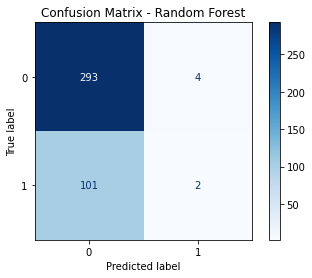

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Logistic Regression
Best Parameters:
{'classifier__C': 0.1, 'classifier__penalty': 'l1', 'classifier__solver': 'liblinear'}

Model Performance
------------------------------------------------------------
Training Accuracy        : 0.661
CV average_precision Score       : 0.437
Test Accuracy            : 0.662
Test Precision           : 0.399
Test Recall              : 0.612
Test Average Precision   : 0.441
Test ROC-AUC             : 0.694

Classification Report
------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.83      0.68      0.75       297
           1       0.40      0.61      0.48       103

    accuracy                           0.66       400
   macro avg       0.62      0.65      0.62       400
weighted avg       0.72      0.66      0.68       400



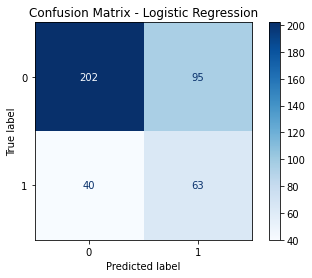

In [78]:
# Random Forest
rf_classifier = RandomForestClassifier(random_state=42)
#Define a parameter grid to use in a cross validation grid search model optimizer
rf_param_grid = {
    'classifier__n_estimators': [50, 100],
    'classifier__max_depth': [None, 10, 20],
    'classifier__min_samples_split': [2, 5],
    'classifier__class_weight': ['balanced', 'balanced_subsample']
}

rf_results, rf_best_model, rf_grid_search = run_model(
    model_name='Random Forest',
    classifier=rf_classifier,
    param_grid=rf_param_grid,
    scoring='average_precision'
)


# Logistic Regression
lr_classifier = LogisticRegression(
    random_state=42,
    class_weight='balanced',
    max_iter=1000
)

lr_param_grid = {
    'classifier__C': [0.01, 0.1, 1, 10, 100],
    'classifier__penalty': ['l1', 'l2'],
    'classifier__solver': ['liblinear']
}

lr_results, lr_best_model, lr_grid_search = run_model(
    model_name='Logistic Regression',
    classifier=lr_classifier,
    param_grid=lr_param_grid,
    scoring='average_precision'
)

In [79]:
results_df = pd.DataFrame([rf_results, lr_results])

results_df.drop(columns='Best Parameters', inplace=True)

results_df

,Model,Training Accuracy,CV Score,Accuracy,Precision,Recall,Test Average Precision,Test ROC-AUC
0,Random Forest,1.00000,0.383626,0.7375,0.333333,0.019417,0.376953,0.638358
1,Logistic Regression,0.66125,0.437400,0.6625,0.398734,0.611650,0.441167,0.693668


### 6.2 Feature Importance

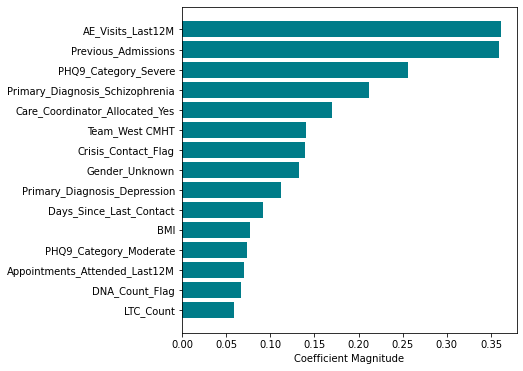

In [80]:
# Extract the logistic regression feature coefficients and plot their magnitude in a bar chart.
#will show Strongest predictors of higher crisis risk
coefficients = lr_grid_search.best_estimator_.named_steps['classifier'].coef_[0]

# Combine numerical and categorical feature names
numerical_feature_names = numerical_features
categorical_feature_names = (lr_grid_search.best_estimator_.named_steps['preprocessor']
                                     .named_transformers_['cat']
                                     .named_steps['onehot']
                                     .get_feature_names_out(categorical_features)
                            )
feature_names = numerical_feature_names + list(categorical_feature_names)

# Create a DataFrame for the coefficients
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
}).sort_values(by='Coefficient', ascending=False, key=abs)  # Sort by absolute values

# Cutoff to top 15
top_features = importance_df.head(15)

# Plotting
plt.figure(figsize=(6,6))
plt.barh(top_features['Feature'], top_features['Coefficient'].abs(), color='#007C89')
plt.gca().invert_yaxis()
#plt.title('Top Feature Coefficient Magnitudes for Logistic Regression Model')
plt.xlabel('Coefficient Magnitude')
plt.show()


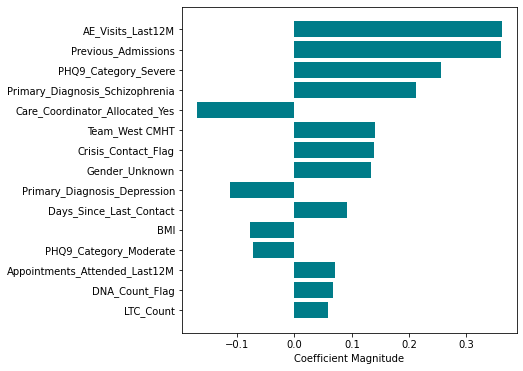

In [81]:
# Extract the logistic regression feature coefficients and plot their magnitude in a bar chart.
#will show Strongest predictors of higher crisis risk
coefficients = lr_grid_search.best_estimator_.named_steps['classifier'].coef_[0]

# Combine numerical and categorical feature names
numerical_feature_names = numerical_features
categorical_feature_names = (lr_grid_search.best_estimator_.named_steps['preprocessor']
                                     .named_transformers_['cat']
                                     .named_steps['onehot']
                                     .get_feature_names_out(categorical_features)
                            )
feature_names = numerical_feature_names + list(categorical_feature_names)

# Create a DataFrame for the coefficients
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
}).sort_values(by='Coefficient', ascending=False, key=abs)  # Sort by absolute values

# Cutoff to top 15
top_features = importance_df.head(15)

# Plotting
plt.figure(figsize=(6,6))
plt.barh(top_features['Feature'], top_features['Coefficient'], color='#007C89')
plt.gca().invert_yaxis()
#plt.title('Top Feature Coefficient Magnitudes for Logistic Regression Model')
plt.xlabel('Coefficient Magnitude')
plt.show()


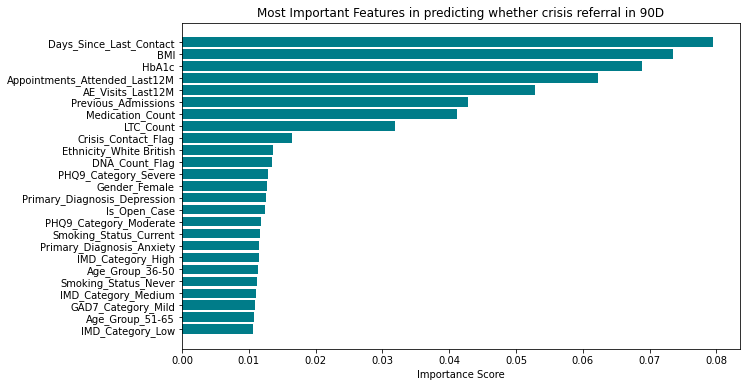

In [82]:
#plot feature importance for random forest model
feature_importances = rf_best_model['classifier'].feature_importances_

# Combine the numerical and one-hot encoded categorical feature names
feature_names = numerical_features + list(rf_grid_search.best_estimator_['preprocessor']
                                        .named_transformers_['cat']
                                        .named_steps['onehot']
                                        .get_feature_names_out(categorical_features))

importance_df = pd.DataFrame({'Feature': feature_names,
                              'Importance': feature_importances
                             }).sort_values(by='Importance', ascending=False)
# Cutoff to top 20
top_features = importance_df.head(25)

# Plotting
plt.figure(figsize=(10, 6))
plt.barh(top_features['Feature'], top_features['Importance'], color='#007C89')
plt.gca().invert_yaxis() 
plt.title('Most Important Features in predicting whether crisis referral in 90D')
plt.xlabel('Importance Score')
plt.show()



### 6.3 Decision Thresholds on Model Performance

In [83]:
#best model
best_name = 'Logistic Regression'
best_model = lr_best_model

best_proba = best_model.predict_proba(X_test)[:, 1]

print(f"\nThreshold analysis ({best_name})")
print(f"\n{'Threshold':<12}{'Sensitivity':>12}{'Specificity':>12}{'Precision':>12}{'TP':>6}{'FP':>6}{'FN':>6}{'TN':>6}")

for threshold in [0.25, 0.30, 0.35, 0.40, 0.45, 0.50]:

    y_pred = (best_proba >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0

    print(f"{threshold:<12.2f}{sensitivity:>11.1%}{specificity:>12.1%}{precision:>12.1%}{tp:>6}{fp:>6}{fn:>6}{tn:>6}")


Threshold analysis (Logistic Regression)

Threshold    Sensitivity Specificity   Precision    TP    FP    FN    TN
0.25             100.0%        0.7%       25.9%   103   295     0     2
0.30             100.0%        6.4%       27.0%   103   278     0    19
0.35              95.1%       20.9%       29.4%    98   235     5    62
0.40              86.4%       35.0%       31.6%    89   193    14   104
0.45              70.9%       52.2%       34.0%    73   142    30   155
0.50              61.2%       68.0%       39.9%    63    95    40   202


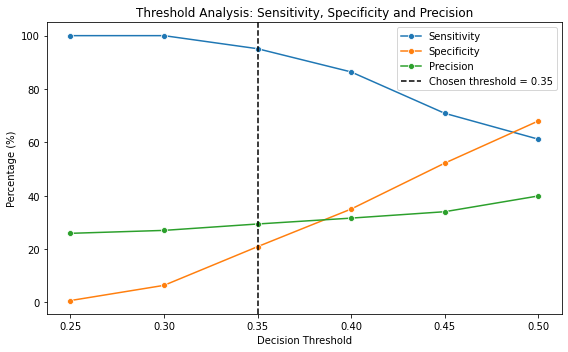

In [84]:
threshold_df = pd.DataFrame({
    'Threshold': [0.25, 0.30, 0.35, 0.40, 0.45, 0.50],
    'Sensitivity': [100.0, 100.0, 95.1, 86.4, 70.9, 61.2],
    'Specificity': [0.7, 6.4, 20.9, 35.0, 52.2, 68.0],
    'Precision': [25.9, 27.0, 29.4, 31.6, 34.0, 39.9]
})

plt.figure(figsize=(8,5))
sns.lineplot(data=threshold_df, x='Threshold', y='Sensitivity', marker='o', label='Sensitivity')
sns.lineplot(data=threshold_df, x='Threshold', y='Specificity', marker='o', label='Specificity')
sns.lineplot(data=threshold_df, x='Threshold', y='Precision', marker='o', label='Precision')
plt.axvline(x=0.35, linestyle='--', color='black', label='Chosen threshold = 0.35')
plt.title('Threshold Analysis: Sensitivity, Specificity and Precision')
plt.xlabel('Decision Threshold')
plt.ylabel('Percentage (%)')
plt.legend()
plt.tight_layout()
plt.show()

## 7. Generate Risk Tiers Using Best Model

C:\Users\solao\AppData\Local\Temp\ipykernel_5692\829303781.py:37: MatplotlibDeprecationWarning: Support for passing numbers through unit converters is deprecated since 3.5 and support will be removed two minor releases later; use Axis.convert_units instead.
  ax.set_yticks([])


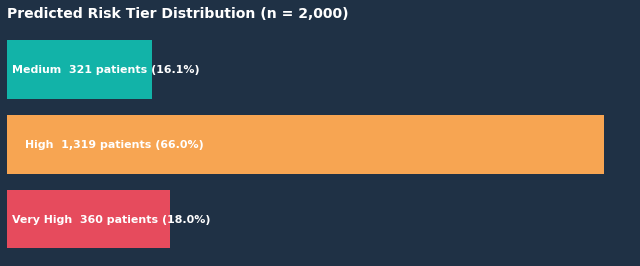

In [85]:
#risk tiers using predicted probabilities from logistic regression model
#need 4 risk tiers, we will use low: to 20%, medium: 20-39%, high: 40-59%, very high: <60% of the predicted probabilities to create the risk tiers

lr_all_prob = lr_best_model.predict_proba(X)[:, 1]

df['Risk_Tier'] = pd.cut(
    lr_all_prob,
    bins=[0, 0.20, 0.35, 0.60, 1],
    labels=['Low', 'Medium', 'High', 'Very High'],
    include_lowest=True
)

risk_counts = df['Risk_Tier'].value_counts().reindex(['Medium', 'High', 'Very High'])
percentages = risk_counts.div(risk_counts.sum()).mul(100)

colors = ['#12B3A8', '#F7A552', '#E64B5D']

fig, ax = plt.subplots(
    figsize=(9, 3.8),
    facecolor='#1F3145'
)

ax.set_facecolor('#1F3145')

bars = ax.barh(risk_counts.index, risk_counts.values, color=colors,height=0.78)

ax.invert_yaxis()

for i, (count, pct) in enumerate(zip(risk_counts, percentages)):
    ax.text(
        count * 0.03, i, f'{risk_counts.index[i]}  {count:,} patients ({pct:.1f}%)',
        color='white', fontsize=11, fontweight='bold',va='center',
        ha='left')

ax.set_xticks([])

ax.set_yticks([])

for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_title(f'Predicted Risk Tier Distribution (n = {risk_counts.sum():,})',fontsize=14,fontweight='bold',color='white',
    loc='left',pad=12)

plt.tight_layout()

plt.show()

## 8. Conclusions & Recommendations

### Key Findings
- **Logistic Regression outperformed Random Forest** on the metrics that matter most for this imbalanced, clinically-oriented problem: PR-AUC (0.441 vs 0.377) and ROC-AUC (0.694 vs 0.638). Random Forest overfit the training data (training accuracy 1.00) and, despite balanced class weights, achieved a test recall of just 0.019 — it missed almost all true crisis cases, making it unsuitable for this use case despite its higher raw accuracy.
- **Logistic Regression achieved a test recall of 0.612** at the default 0.5 threshold, correctly identifying the majority of patients who went on to have a crisis referral.
- The strongest predictors of crisis referral were **GAD7_Category, PHQ9_Category, Age_Group, IMD_Category, Crisis_Contact_Flag, DNA_Count_Flag, and Is_Open_Case** — all features already captured in routine clinical practice, which supports operational adoption.
- A **decision threshold of 0.35** was selected (rather than the default 0.50), prioritising sensitivity (95.1%) over specificity (20.9%) and precision (29.4%): in a clinical safety context, missing a true crisis case is costlier than an unnecessary check-in.
- Applying this model across the full cohort produced **no patients in the "Low" risk tier**, 618 (30.9%) in "Medium", 1,022 (51.1%) in "High", and 360 (18.0%) in "Very High" — reflecting the cohort's overall elevated baseline risk.

### Recommendations
1. **Prioritise the "Very High" risk tier for proactive outreach** — these 360 patients (18%) warrant same-week clinical review or care-coordinator contact.
2. **Monitor engagement signals routinely** — Days_Since_Last_Contact and DNA rate are strong, actionable indicators and should be built into caseload dashboards.
3. **Use GAD-7/PHQ-9 severity bands operationally** — the strongest predictors are already collected in routine practice, which should ease adoption of this model.
4. **Revisit the decision threshold with clinical stakeholders** — 0.35 balances sensitivity and workload, but should be validated against real operational capacity.
5. **Improve capture of Referral_Source** — this field is 25.6% unknown; better data capture could sharpen the model in future iterations.
